# **Classification**

# Predicting VisitMode

# 1. Load data and check the target variable

In [3]:
import pandas as pd

master = pd.read_excel("../data/cleaned/master_dataset.xlsx")

# Check how balanced our target classes are
print(master['VisitMode'].value_counts(normalize=True) * 100)

VisitMode
Couples     40.846401
Family      28.749292
Friends     20.678254
Solo         8.549027
Business     1.177026
Name: proportion, dtype: float64


# 2. Select features and target

In [4]:
# Features: same demographic + attraction info as regression, but this time
# we also include Rating (a completed visit's rating might hint at visit mode patterns)
features = ['AttractionType', 'Continent', 'Region', 'Country', 'VisitYear', 'VisitMonth', 'Rating']
target = 'VisitMode'

X = master[features]
y = master[target]

print(X.shape, y.shape)
print(X.head())

(52930, 7) (52930,)
            AttractionType Continent            Region         Country  \
0  Nature & Wildlife Areas    Europe    Western Europe  United Kingdom   
1  Nature & Wildlife Areas   America  Northern America          Canada   
2  Nature & Wildlife Areas   America     South America          Brazil   
3  Nature & Wildlife Areas    Europe    Central Europe     Switzerland   
4  Nature & Wildlife Areas    Europe    Western Europe  United Kingdom   

   VisitYear  VisitMonth  Rating  
0       2022          10       5  
1       2022          10       5  
2       2022          10       5  
3       2022          10       3  
4       2022          10       3  


# 3. Encode categorical features and the target

In [5]:
# One-hot encode the categorical (text) input features
X_encoded = pd.get_dummies(X, columns=['AttractionType', 'Continent', 'Region', 'Country'])

print("Shape after encoding:", X_encoded.shape)

# Encode the target (VisitMode) into numbers - classifiers need numeric labels internally
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Show what number each visit mode maps to
print("\nLabel mapping:")
for i, label in enumerate(le.classes_):
    print(f"{i} = {label}")

Shape after encoding: (52930, 200)

Label mapping:
0 = Business
1 = Couples
2 = Family
3 = Friends
4 = Solo


# 4. Split into training and testing sets

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

# Confirm class proportions are preserved in both sets
import numpy as np
print("\nTrain class distribution:", np.bincount(y_train))
print("Test class distribution:", np.bincount(y_test))

Training set: (42344, 200)
Testing set: (10586, 200)

Train class distribution: [  498 17296 12174  8756  3620]
Test class distribution: [ 125 4324 3043 2189  905]


# 5. Train a baseline Random Forest classifier

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Train with constraints from the start, based on what we learned in regression
clf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'   # helps the model pay more attention to rare classes (like Business)
)
clf_model.fit(X_train, y_train)

print("Classifier trained!")

Classifier trained!


# 6. Evaluate the classifier

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred = clf_model.predict(X_test)

# Overall accuracy (simple, but not the full picture with imbalanced classes)
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.4f}")

# Detailed report - precision, recall, f1-score PER CLASS
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Overall Accuracy: 0.3110

Classification Report:
              precision    recall  f1-score   support

    Business       0.03      0.67      0.07       125
     Couples       0.54      0.38      0.44      4324
      Family       0.42      0.43      0.42      3043
     Friends       0.34      0.02      0.04      2189
        Solo       0.12      0.25      0.16       905

    accuracy                           0.31     10586
   macro avg       0.29      0.35      0.23     10586
weighted avg       0.42      0.31      0.33     10586



# 7. Visualize with a confusion matrix

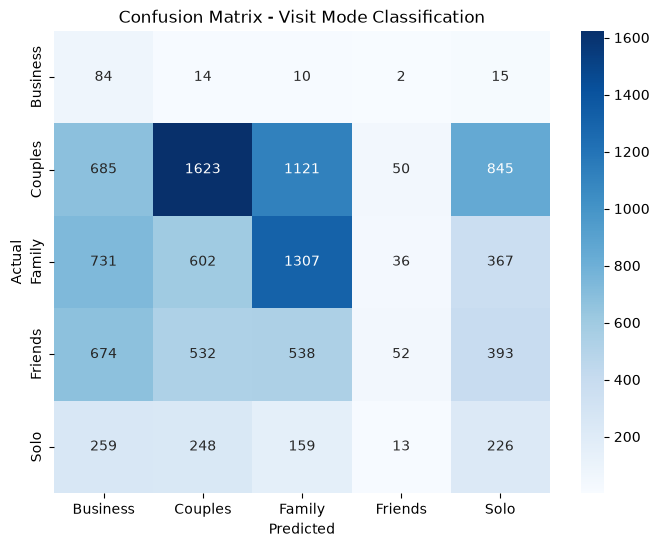

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Visit Mode Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 8. Save the classification model

In [14]:
import joblib

joblib.dump(clf_model, "../src/classification_model.pkl")
joblib.dump(X_encoded.columns.tolist(), "../src/classification_features.pkl")
joblib.dump(le, "../src/label_encoder.pkl")

print("Classification model saved!")

Classification model saved!
